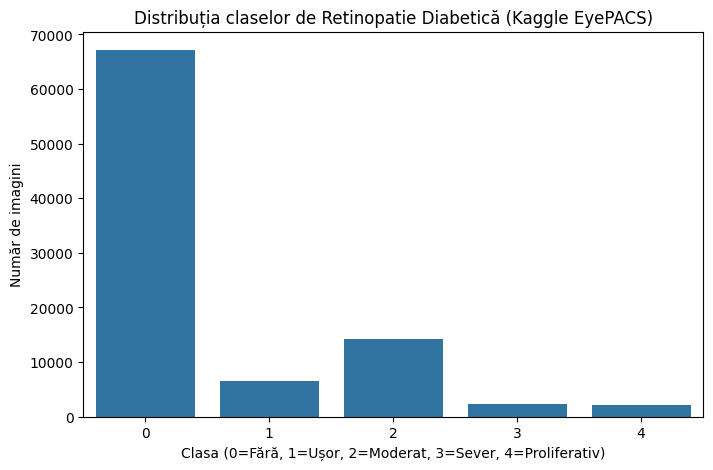

Numărul total de imagini: 92364
Numărul de imagini pe clasă:
diagnosis
0    67148
2    14152
1     6575
3     2280
4     2209
Name: count, dtype: int64
Imaginea Datasets/Dataset_KaggleEyePACS/resized_traintest15_train19/10_left.png lipsește din folder.
Imaginea Datasets/Dataset_KaggleEyePACS/resized_traintest15_train19/15_left.png lipsește din folder.
Imaginea Datasets/Dataset_KaggleEyePACS/resized_traintest15_train19/15_right.png lipsește din folder.
Imaginea Datasets/Dataset_KaggleEyePACS/resized_traintest15_train19/99_left.png lipsește din folder.
Imaginea Datasets/Dataset_KaggleEyePACS/resized_traintest15_train19/16_left.png lipsește din folder.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
import os

# 1. Definim calea către folderul EyePACS (Ajustează dacă e necesar)
base_dir = 'Datasets/Dataset_KaggleEyePACS'
csv_path = f'{base_dir}/labels/traintestLabels15_trainLabels19.csv'
img_dir = f'{base_dir}/resized_traintest15_train19'

# 2. Citim fișierul CSV
df = pd.read_csv(csv_path)

# 3. Redenumim coloanele pentru a păstra compatibilitatea cu restul codului tău
df = df.rename(columns={'image': 'id_code', 'level': 'diagnosis'})

# Vizualizarea distribuției claselor
plt.figure(figsize=(8, 5))
sns.countplot(x='diagnosis', data=df)
plt.title('Distribuția claselor de Retinopatie Diabetică (Kaggle EyePACS)')
plt.xlabel('Clasa (0=Fără, 1=Ușor, 2=Moderat, 3=Sever, 4=Proliferativ)')
plt.ylabel('Număr de imagini')
plt.show()

# Afișează numărul de imagini
print("Numărul total de imagini:", len(df))
print("Numărul de imagini pe clasă:")
print(df['diagnosis'].value_counts())

# Afișează o imagine pentru fiecare clasă
for diagnosis in sorted(df['diagnosis'].unique()):
    img_name = df[df['diagnosis'] == diagnosis]['id_code'].iloc[0]
    
    # EyePACS folosește nativ .jpeg, dar verificăm și .png pentru siguranță
    img_path = os.path.join(img_dir, f"{img_name}.jpeg")
    if not os.path.exists(img_path):
        img_path = os.path.join(img_dir, f"{img_name}.png")
        
    try:
        img = mpimg.imread(img_path)
        plt.imshow(img)
        plt.title(f'Clasa: {diagnosis}')
        plt.axis('off')
        plt.show()
    except FileNotFoundError:
        print(f"Imaginea {img_path} lipsește din folder.")

In [8]:
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class DiabeticRetinopathyDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        # Resetăm indexul pentru a evita erori la iterare după split
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Extragem numele de bază al imaginii
        img_name = str(self.dataframe.iloc[idx]['id_code'])
        
        # Generăm calea (EyePACS folosește de regulă .jpeg)
        img_path = os.path.join(self.image_dir, f"{img_name}.jpeg")
        if not os.path.exists(img_path):
            img_path = os.path.join(self.image_dir, f"{img_name}.png")
            if not os.path.exists(img_path):
                 img_path = os.path.join(self.image_dir, f"{img_name}.jpg")
        
        # Încărcare imagine RGB
        try:
            image = Image.open(img_path).convert('RGB')
        except FileNotFoundError:
            # Dacă lipsește o poză, returnăm un tensor negru ca să nu crape antrenarea
            image = Image.new('RGB', (224, 224), (0, 0, 0))
            
        label = int(self.dataframe.iloc[idx]['diagnosis'])

        if self.transform:
            image = self.transform(image)

        return image, label

# Transformări pentru antrenare (Augmentare)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # Standard ImageNet
                         std=[0.229, 0.224, 0.225])
])

# Transformări pentru validare/testare
eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [9]:
from sklearn.model_selection import train_test_split

# 1. Împărțim setul masiv în: 80% Train, 10% Validare, 10% Testare
# Stratify asigură că proporția claselor (0,1,2,3,4) este păstrată egal în toate cele 3 seturi
train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['diagnosis'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['diagnosis'])

print(f"Imagini alocate -> Antrenare: {len(train_df)} | Validare: {len(val_df)} | Testare: {len(test_df)}")

# 2. Crearea Dataset-urilor folosind direct folderul de imagini EyePACS
train_dataset = DiabeticRetinopathyDataset(train_df, img_dir, transform=train_transforms)
val_dataset = DiabeticRetinopathyDataset(val_df, img_dir, transform=eval_transforms)
test_dataset = DiabeticRetinopathyDataset(test_df, img_dir, transform=eval_transforms)

# 3. Crearea DataLoader-elor
# Este recomandat să reduci num_workers=4 (în loc de 8) când ai ~70.000 imagini de antrenare
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

print("DataLoaders sunt pregătite pentru antrenament!")

Imagini alocate -> Antrenare: 73891 | Validare: 9236 | Testare: 9237
DataLoaders sunt pregătite pentru antrenament!


In [10]:
import torchvision.models as models
import torch.nn as nn

def create_model(num_classes=5):
    # Încărcăm modelul pre-antrenat pe ImageNet
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    
    # Înghețăm straturile de bază (opțional, dar recomandat inițial)
    for param in model.parameters():
        param.requires_grad = False
        
    # Modificăm ultimul strat Fully Connected
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 512),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(512, num_classes)
    )
    
    # Deblocăm ultimul strat pentru a învăța
    for param in model.fc.parameters():
        param.requires_grad = True
        
    return model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_model().to(device)
print(f"Modelul rulează pe: {device}")

Modelul rulează pe: cuda


In [11]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [12]:
from sklearn.model_selection import train_test_split
import torch.optim as optim
from tqdm import tqdm

# Funcția de Loss și Optimizatorul
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.0001)

EPOCHS = 20
best_val_acc = 0.0
best_acc = 0.0
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# BUCLA DE ANTRENARE ȘI VALIDARE
for epoch in range(EPOCHS):
    # --- Faza de Antrenare ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    for images, labels in tqdm(train_loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    train_acc = 100 * correct / total
    train_accuracies.append(train_acc)
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    
    # --- Faza de Validare ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    val_acc = 100 * val_correct / val_total
    val_accuracies.append(val_acc)
    val_loss = val_loss / len(val_loader)
    val_losses.append(val_loss)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print("=====================================================")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    # Salvarea celui mai bun model bazat strict pe datele de validare
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_dr_model.pth')
        print(">>> Nou model de top salvat!")
    val_accuracies.append(val_acc)

    # Salvăm cel mai bun model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_dr_model.pth')
        print("Model salvat!")


Epoch 1/20


Training: 100%|██████████| 2310/2310 [02:57<00:00, 13.00it/s]


Train Loss: 0.8171 | Train Acc: 73.39%
Val Loss: 0.7825 | Val Acc: 74.34%
>>> Nou model de top salvat!
Model salvat!

Epoch 2/20


Training: 100%|██████████| 2310/2310 [03:07<00:00, 12.32it/s]


Train Loss: 0.7652 | Train Acc: 74.29%
Val Loss: 0.7612 | Val Acc: 74.64%
>>> Nou model de top salvat!
Model salvat!

Epoch 3/20


...

Train Loss: 0.7087 | Train Acc: 76.01%
Val Loss: 0.7188 | Val Acc: 75.83%

Epoch 19/20


Training: 100%|██████████| 2310/2310 [02:56<00:00, 13.06it/s]


Train Loss: 0.7066 | Train Acc: 76.05%
Val Loss: 0.7174 | Val Acc: 76.02%
>>> Nou model de top salvat!
Model salvat!

Epoch 20/20


Training: 100%|██████████| 2310/2310 [03:03<00:00, 12.56it/s]


Train Loss: 0.7079 | Train Acc: 75.96%
Val Loss: 0.7167 | Val Acc: 75.92%



--- ÎNCEPE FAZA DE TESTARE ---


Testing: 100%|██████████| 289/289 [00:24<00:00, 12.01it/s]



Acuratețea finală pe setul de TEST: 76.04%

Scorul Quadratic Weighted Kappa (QWK): 0.4590
(Un scor peste 0.7 este considerat bun în imagistica medicală)


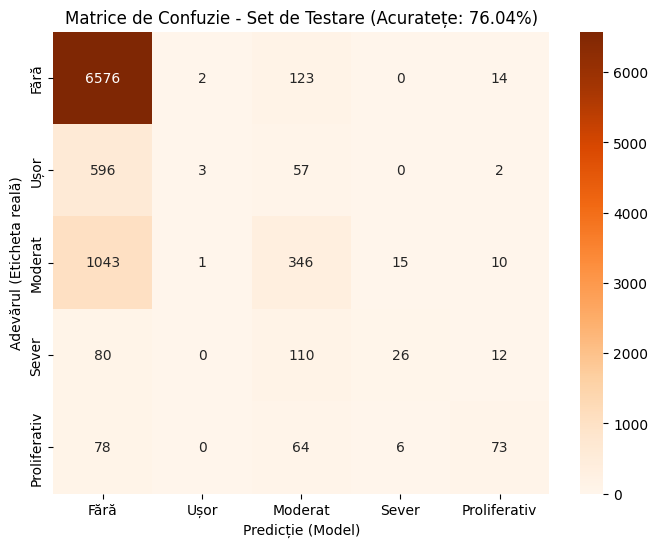


Raport de Clasificare:
                  precision    recall  f1-score   support

        Fără (0)       0.79      0.98      0.87      6715
        Ușor (1)       0.50      0.00      0.01       658
     Moderat (2)       0.49      0.24      0.33      1415
       Sever (3)       0.55      0.11      0.19       228
Proliferativ (4)       0.66      0.33      0.44       221

        accuracy                           0.76      9237
       macro avg       0.60      0.33      0.37      9237
    weighted avg       0.71      0.76      0.70      9237



In [13]:
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n--- ÎNCEPE FAZA DE TESTARE ---")

# Încărcăm cel mai bun model
model.load_state_dict(torch.load('best_dr_model.pth'))
model.eval()

test_correct = 0
test_total = 0
test_preds = []
test_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        
        _, predicted = torch.max(outputs.data, 1)
        
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        
        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

test_acc = 100 * test_correct / test_total
print(f"\nAcuratețea finală pe setul de TEST: {test_acc:.2f}%\n")

# Calculăm Quadratic Weighted Kappa
qwk = cohen_kappa_score(test_labels, test_preds, weights='quadratic')
print(f"Scorul Quadratic Weighted Kappa (QWK): {qwk:.4f}")
print("(Un scor peste 0.7 este considerat bun în imagistica medicală)")

# Generarea Matricei de Confuzie
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Fără', 'Ușor', 'Moderat', 'Sever', 'Proliferativ'], 
            yticklabels=['Fără', 'Ușor', 'Moderat', 'Sever', 'Proliferativ'])
plt.xlabel('Predicție (Model)')
plt.ylabel('Adevărul (Eticheta reală)')
plt.title(f'Matrice de Confuzie - Set de Testare (Acuratețe: {test_acc:.2f}%)')
plt.show()

# Raport detaliat (Precision, Recall, F1-Score)
print("\nRaport de Clasificare:")
print(classification_report(test_labels, test_preds, target_names=['Fără (0)', 'Ușor (1)', 'Moderat (2)', 'Sever (3)', 'Proliferativ (4)']))

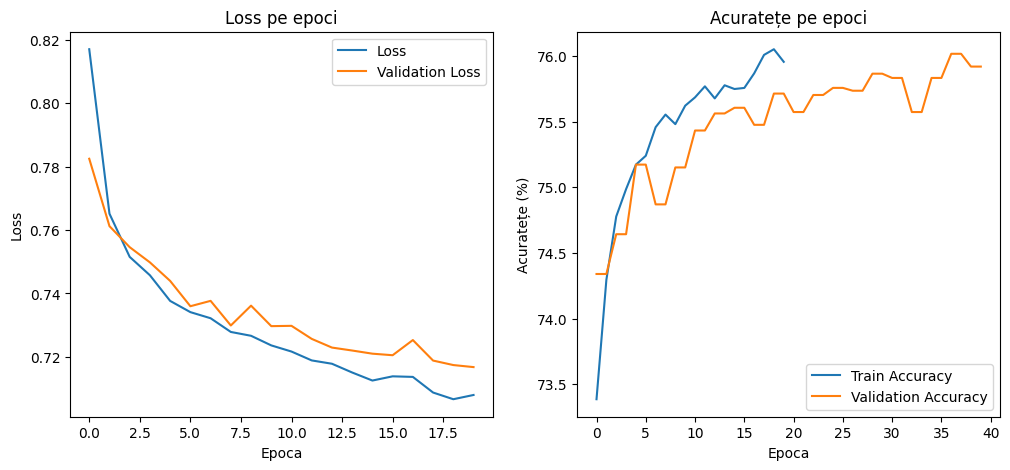

In [14]:
# Grafice pentru loss + acuratețe
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss pe epoci')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Acuratețe pe epoci')
plt.xlabel('Epoca')
plt.ylabel('Acuratețe (%)')
plt.legend()
plt.show()

In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Generarea matricei de confuzie
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
plt.xlabel('Predicție (Model)')
plt.ylabel('Adevărul (Medic)')
plt.title('Matricea de Confuzie pentru Retinopatia Diabetică')
plt.show()

# Raport detaliat
print(classification_report(all_labels, all_preds, target_names=['Fără', 'Ușor', 'Moderat', 'Sever', 'Proliferativ']))

NameError: name 'all_labels' is not defined